In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
import sys

In [2]:
import sklearn
print(sklearn.__version__)

1.3.2


In [3]:
import warnings
# Suppress all FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)


# gene expression values

In [4]:
genetic = pd.read_csv("Expression_log2_21_primaryNivo_braun_2020.csv",index_col=0)
genetic

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2MP1,A3GALT2,A4GALT,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
gene_name,,,,,,,,,,,,,,,,,,,,,
G138701_RCCBMS-00020-T_v1_RNA_OnPrem,30.187983,22.999432,33.643965,37.130851,22.705126,22.869853,21.076515,21.271282,21.807184,33.279532,...,33.26816,30.04056,30.36292,30.98129,32.38442,28.01561,31.24379,33.81903,33.22469,31.23383
G138701_RCCBMS-00097-T_v1_RNA_OnPrem,30.483638,25.581769,28.866645,37.945043,27.797609,24.142100,21.076515,21.271282,21.807184,33.019435,...,31.53633,29.94062,30.80829,30.74475,32.09470,26.32526,32.70057,33.67262,33.10198,32.44643
G138701_RCCBMS-00141-T_v1_RNA_OnPrem,30.092851,26.933385,26.684228,36.851946,22.705126,30.406352,21.076515,21.271282,21.807184,31.033210,...,30.74474,31.95812,30.73898,30.15898,31.69473,26.33098,32.68330,33.96047,32.97135,32.20607
G138701_RCCBMS-00099-T_v1_RNA_OnPrem,30.975010,26.683128,32.521494,38.453517,26.337846,28.229357,21.076515,21.271282,26.484608,33.009203,...,31.63196,30.71732,31.09654,30.25757,31.90774,27.53819,32.64194,34.54254,33.24885,32.78278
G138701_RCCBMS-00163-T_v1_RNA_OnPrem,26.915750,22.999432,23.219176,38.931987,22.705126,22.869853,21.076515,21.271282,21.807184,31.447751,...,31.75620,30.75149,30.55896,30.17101,31.01545,21.45312,32.86620,34.24375,34.86720,32.73361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P66507-04D-Run1_S3_L001,29.718678,21.286965,33.059162,35.566022,21.357557,27.686244,20.980667,25.034267,21.018133,33.704298,...,28.60179,30.27215,31.08287,31.21266,33.18573,29.26041,31.70839,32.97611,34.23396,32.87393
P66507-07G-Run1_S17_L002,31.147910,21.286965,31.617351,37.423994,21.357557,27.720569,20.980667,20.992693,28.011280,35.638479,...,26.14211,31.31652,31.24066,31.34713,33.06662,27.08693,30.62278,35.10264,33.68084,30.73622
P66425-03B-Run1_S10_L001,30.099518,25.040893,33.891608,38.289830,21.357557,26.870362,20.980667,20.992693,21.018133,33.654328,...,32.54706,29.97152,31.22229,30.38211,31.30604,27.29504,32.44263,34.20699,32.80918,32.29759


In [5]:
cl = pd.read_csv("braun_data_clinical_data.csv",index_col=0)
dfcl = cl.loc[genetic.index,:][cl["Benefit"].isin(["CB","NCB"])]

/tmp/ipykernel_769699/3204985976.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfcl = cl.loc[genetic.index,:][cl["Benefit"].isin(["CB","NCB"])]


In [6]:
dfmerge = pd.merge(genetic.reset_index(),cl.reset_index(),how='left', left_on="gene_name", right_on="RNA_ID")
dfmerge.shape

(133, 20561)

In [11]:
genetic.loc[dfcl.index.tolist()].var().sort_values()[-5000:].index.tolist()

HSD11B2       5.139755
TUBA3C        5.140328
CDK5R1        5.141656
PKD2L2        5.142461
ARAP1-AS2     5.143007
               ...    
IGKV2D-30    27.272571
IGKV1D-33    29.634065
IGKV2D-28    31.603601
IGKV1-33     32.983287
MIR663AHG    44.510921
Length: 5000, dtype: float64

In [12]:
modelinput_expr = genetic.loc[dfcl.index.tolist(),] #genetic.loc[dfcl.index.tolist()].var().sort_values()[-5000:].index.tolist()
print(modelinput_expr.shape)
modeltarget_expr = dfcl["Benefit"].replace("NCB",0).replace("CB",1).tolist()

(90, 5000)


In [14]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import OneHotEncoder
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import  LogisticRegression, SGDClassifier
from sklearn import metrics
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import RocCurveDisplay

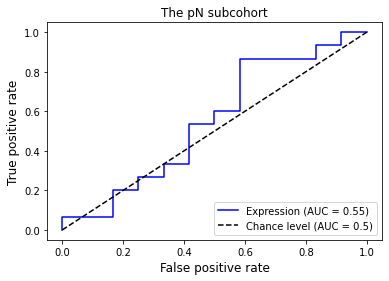

lr准确率： 0.5555555555555556
lr的其他指标：
               precision    recall  f1-score   support

          CB       0.59      0.67      0.62        15
         NCB       0.50      0.42      0.45        12

    accuracy                           0.56        27
   macro avg       0.54      0.54      0.54        27
weighted avg       0.55      0.56      0.55        27



In [15]:
X_train, X_test, y_train, y_test = train_test_split(modelinput_expr, 
                                                     dfcl["Benefit"],
                                                   test_size=0.3,random_state=0)

base_model = LogisticRegression(penalty='l2', C=1, max_iter=1000, random_state=42, class_weight='balanced')

# Combine feature selection and model into a pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('feature_selection', SelectKBest( k=20)),
    ('logistic_regression', base_model)
])

# Fit the pipeline on training data
pipeline.fit(X_train, y_train)

lr_y_predict = pipeline.predict(X_test)

#fig, ax = plt.subplots() 
RocCurveDisplay.from_estimator(pipeline,X_test, y_test,pos_label="CB",plot_chance_level=True,name=f"Expression",c="blue")
plt.title('The pN subcohort',fontsize=12)
plt.ylabel("True positive rate",fontsize=12)
plt.xlabel("False positive rate",fontsize=12)
#plt.savefig(f"expression_AUC.svg",dpi=600,bbox_inches='tight')
plt.show()

print("lr准确率：", pipeline.score(X_test, y_test))
print("lr的其他指标：\n", classification_report(y_test, lr_y_predict, target_names=["CB", "NCB"],zero_division=0.0))


In [16]:
X = modelinput_expr.copy()
y = dfcl["Benefit"].copy()

In [17]:
X.shape

(90, 5000)

In [18]:
# Spot Check Algorithms
from sklearn.svm import SVC
from sklearn.linear_model import  LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.neural_network import MLPClassifier

In [19]:
for datetype,dataname in \
    zip([ modelinput_expr.copy()],\
        ["expression"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    models.append(('SVC',SVC(class_weight='balanced')))       
    models.append(('RF', RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced')))
    models.append(('DNN',MLPClassifier(activation='relu',solver='adam',random_state=42,max_iter=1000)))
   
    
    dic_model = {}
    for name, model in models:
        results = []
        names = []
        for i in range(1,11):
            score_k = []
            # Define leave-one-out cross-validation
            loo = LeaveOneOut()
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            
            for train_index, test_index in loo.split(datetype):
                # Create a pipeline
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('feature_selection', SelectKBest(score_func=f_classif,k=i*10)), 
                    ('logistic_regression', model)       # Logistic Regression model
            ])
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)
                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
                #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        dic_model[name] = results

LR 0.6444444444444445
LR 0.6111111111111112
LR 0.5333333333333333
LR 0.4888888888888889
LR 0.4888888888888889
LR 0.5
LR 0.4888888888888889
LR 0.5444444444444444
LR 0.5555555555555556
LR 0.5333333333333333
SVC 0.5666666666666667
SVC 0.5333333333333333
SVC 0.4666666666666667
SVC 0.4777777777777778
SVC 0.4666666666666667
SVC 0.4666666666666667
SVC 0.5
SVC 0.5444444444444444
SVC 0.5777777777777777
SVC 0.5555555555555556
RF 0.6
RF 0.43333333333333335
RF 0.4222222222222222
RF 0.36666666666666664
RF 0.4222222222222222
RF 0.4666666666666667
RF 0.45555555555555555
RF 0.5
RF 0.4111111111111111
RF 0.4111111111111111
DNN 0.5222222222222223
DNN 0.5555555555555556
DNN 0.4777777777777778
DNN 0.5111111111111111
DNN 0.5555555555555556
DNN 0.5
DNN 0.4888888888888889
DNN 0.5555555555555556
DNN 0.5777777777777777
DNN 0.5666666666666667


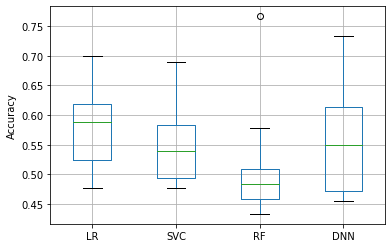

In [20]:
df_expr_plot = pd.DataFrame.from_dict(dic_model)
df_expr_plot.boxplot()
plt.ylabel("Accuracy")
plt.savefig("gene_expression_ML-EXPR_models.svg",dpi=300)

# network features input are avaiable:

In [11]:
edges_read = pd.read_csv("primaryNivo_common_edges_adjusted+var10000.txt",index_col=0)

edges_selected = edges_read.copy()
edges_input = edges_selected.loc[modelinput_expr.index,:]

In [12]:
from sklearn.feature_selection import SequentialFeatureSelector

In [15]:
# Spot Check Algorithms
# edges_input


from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ edges_input.copy()],\
        ["edges"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    models.append(('SVC',SVC(class_weight='balanced')))       
    models.append(('RF', RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced')))
    models.append(('DNN',MLPClassifier(activation='relu',solver='adam',random_state=42,max_iter=1000)))
   
    
    dic_model_edges = {}
    for name, model in models:
        results = []
        names = []
        for i in range(1,11):
            score_k = []
            # Define leave-one-out cross-validation
            loo = LeaveOneOut()
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            
            for train_index, test_index in loo.split(datetype):
                # Create a pipeline
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('feature_selection', SelectKBest(score_func=f_classif,k=i*10)), 
                    ('logistic_regression', model)       # Logistic Regression model
            ])
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)
                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
                #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        dic_model_edges[name] = results

LR 0.4777777777777778
LR 0.5333333333333333
LR 0.6666666666666666
LR 0.6888888888888889
LR 0.7333333333333333
LR 0.6777777777777778
LR 0.6888888888888889
LR 0.7
LR 0.6111111111111112
LR 0.5111111111111111
SVC 0.5444444444444444
SVC 0.5555555555555556
SVC 0.5666666666666667
SVC 0.5666666666666667
SVC 0.6
SVC 0.6666666666666666
SVC 0.6555555555555556
SVC 0.6444444444444445
SVC 0.6
SVC 0.5666666666666667
RF 0.5111111111111111
RF 0.5777777777777777
RF 0.5333333333333333
RF 0.5111111111111111
RF 0.5555555555555556
RF 0.5777777777777777
RF 0.5666666666666667
RF 0.5333333333333333
RF 0.5333333333333333
RF 0.5444444444444444
DNN 0.4777777777777778
DNN 0.5555555555555556
DNN 0.6111111111111112
DNN 0.6555555555555556
DNN 0.6777777777777778
DNN 0.6666666666666666
DNN 0.6777777777777778
DNN 0.6666666666666666
DNN 0.5333333333333333
DNN 0.4777777777777778


[0.4777777777777778, 0.5333333333333333, 0.6666666666666666, 0.6888888888888889, 0.7333333333333333, 0.6777777777777778, 0.6888888888888889, 0.7, 0.6111111111111112, 0.5111111111111111]


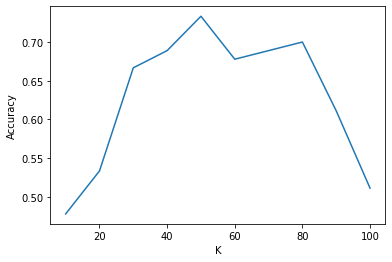

In [19]:
dic_model_edges
import matplotlib.pyplot as plt
print(dic_model_edges["LR"])
plt.plot([i*10 for i in range(1,11)],dic_model_edges["LR"])
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.savefig("edges_ML-LR_K.svg",dpi=300)

[0.5444444444444444, 0.5555555555555556, 0.5666666666666667, 0.5666666666666667, 0.6, 0.6666666666666666, 0.6555555555555556, 0.6444444444444445, 0.6, 0.5666666666666667]


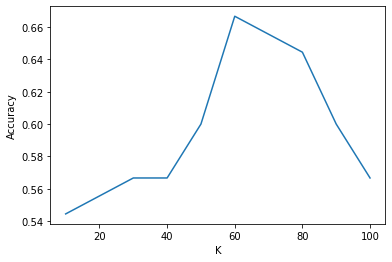

In [22]:
dic_model_edges
import matplotlib.pyplot as plt
print(dic_model_edges["SVC"])
plt.plot([i*10 for i in range(1,11)],dic_model_edges["SVC"])
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.savefig("edges_ML-SVC_K.svg",dpi=300)

In [ ]:
dic_model_edges
import matplotlib.pyplot as plt
print(dic_model_edges["SVC"])
plt.plot([i*10 for i in range(1,11)],dic_model_edges["SVC"])
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.savefig("edges_ML-SVC_K.svg",dpi=300)

[0.5111111111111111, 0.5777777777777777, 0.5333333333333333, 0.5111111111111111, 0.5555555555555556, 0.5777777777777777, 0.5666666666666667, 0.5333333333333333, 0.5333333333333333, 0.5444444444444444]


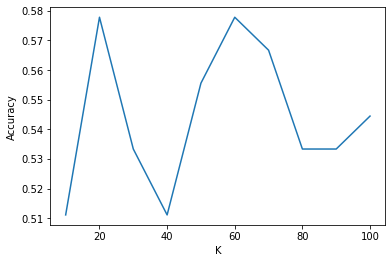

In [23]:
dic_model_edges
import matplotlib.pyplot as plt
print(dic_model_edges["RF"])
plt.plot([i*10 for i in range(1,11)],dic_model_edges["RF"])
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.savefig("edges_ML-RF_K.svg",dpi=300)

[0.4777777777777778, 0.5555555555555556, 0.6111111111111112, 0.6555555555555556, 0.6777777777777778, 0.6666666666666666, 0.6777777777777778, 0.6666666666666666, 0.5333333333333333, 0.4777777777777778]


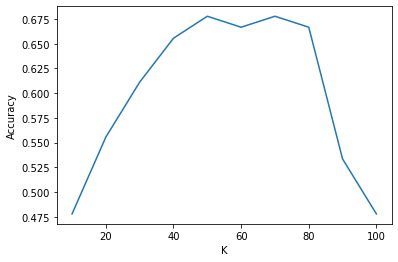

In [24]:
dic_model_edges
import matplotlib.pyplot as plt
print(dic_model_edges["DNN"])
plt.plot([i*10 for i in range(1,11)],dic_model_edges["DNN"])
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.savefig("edges_ML-DNN_K.svg",dpi=300)

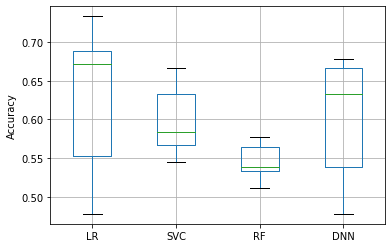

In [24]:
df_edges_plot = pd.DataFrame.from_dict(dic_model_edges)
df_edges_plot.boxplot()
plt.ylabel("Accuracy")
plt.savefig("edges_ML_models.svg",dpi=300)

# combination of gene expression and gene coexpression

In [25]:
modelinput_expr.join(edges_input,lsuffix='expr', rsuffix='edges')

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2MP1,A3GALT2,A4GALT,...,HSD3B7_USP34,STK11_TAB2,ITCH_TUBGCP6,NIPBL_TGFB1,ETAA1_LRCH4,EIF3E_IL11RA,CCDC142_CSDE1,CCNL2_NEDD1,RPL37_STK11,ACTR2_ATG16L2
gene_name,,,,,,,,,,,,,,,,,,,,,
G138701_RCCBMS-00020-T_v1_RNA_OnPrem,30.187983,22.999432,33.643965,37.130851,22.705126,22.869853,21.076515,21.271282,21.807184,33.279532,...,-0.642597,-0.651356,-0.594918,-0.585138,-0.507149,-0.625087,-0.550042,-0.545841,-0.492360,-0.520370
G138701_RCCBMS-00097-T_v1_RNA_OnPrem,30.483638,25.581769,28.866645,37.945043,27.797609,24.142100,21.076515,21.271282,21.807184,33.019435,...,-0.535085,-0.651356,-0.529483,-0.585138,-0.507149,-0.519079,-0.550042,-0.479363,-0.492360,-0.520370
G138701_RCCBMS-00141-T_v1_RNA_OnPrem,30.092851,26.933385,26.684228,36.851946,22.705126,30.406352,21.076515,21.271282,21.807184,31.033210,...,-0.642597,-0.548588,-0.476628,-0.585138,-0.635350,-0.519079,-0.550042,-0.537486,-0.594656,-0.520370
G138701_RCCBMS-00099-T_v1_RNA_OnPrem,30.975010,26.683128,32.521494,38.453517,26.337846,28.229357,21.076515,21.271282,26.484608,33.009203,...,-0.642597,-0.548588,-0.594918,-0.585138,-0.561262,-0.519079,-0.550042,-0.543265,-0.594656,-0.623699
G138701_RCCBMS-00053-T_v1_RNA_OnPrem,30.731451,22.999432,25.282264,37.915010,22.705126,28.859039,21.076515,21.271282,21.807184,31.851192,...,-0.535085,-0.651356,-0.476628,-0.585138,-0.507149,-0.625087,-0.652548,-0.607391,-0.594656,-0.623699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EA639040,31.805473,26.396573,32.109799,37.371641,27.068437,26.405412,20.976688,20.889661,24.824862,33.061771,...,-0.535085,-0.651356,-0.594918,-0.585138,-0.635350,-0.625087,-0.652548,-0.607391,-0.594656,-0.623699
P66507-04D-Run1_S3_L001,29.718678,21.286965,33.059162,35.566022,21.357557,27.686244,20.980667,25.034267,21.018133,33.704298,...,-0.535085,-0.651356,-0.476628,-0.476673,-0.561760,-0.519079,-0.652548,-0.607391,-0.594656,-0.520370
P66507-07G-Run1_S17_L002,31.147910,21.286965,31.617351,37.423994,21.357557,27.720569,20.980667,20.992693,28.011280,35.638479,...,-0.642597,-0.651356,-0.594918,-0.585138,-0.635350,-0.625087,-0.550042,-0.607391,-0.594656,-0.623699


In [ ]:
# Spot Check Algorithms
# edges_input

dic_model_edges_expr = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ modelinput_expr.join(edges_input,lsuffix='expr', rsuffix='edges').copy()],\
        ["expression+edges"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    models.append(('SVC',SVC(class_weight='balanced')))       
    models.append(('RF', RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced')))
    models.append(('DNN',MLPClassifier(activation='relu',solver='adam',random_state=42,max_iter=1000)))
   
    
    dic_model_edges = {}
    for name, model in models:
        results = []
        names = []
        for i in range(1,11):
            # Define leave-one-out cross-validation
            loo = LeaveOneOut()
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            
            for train_index, test_index in loo.split(datetype):
                # Create a pipeline
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('feature_selection', SelectKBest(score_func=f_classif,k=i*10)), 
                    ('logistic_regression', model)       # Logistic Regression model
            ])
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)
                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
                #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        dic_model_edges_expr[name] = results
        

In [26]:
dic_model_edges_expr

{'LR': [0.4,
  0.6333333333333333,
  0.6777777777777778,
  0.7333333333333333,
  0.7555555555555555,
  0.7111111111111111,
  0.6777777777777778,
  0.7222222222222222,
  0.7222222222222222,
  0.7222222222222222]}

[0.4, 0.6333333333333333, 0.6777777777777778, 0.7333333333333333, 0.7555555555555555, 0.7111111111111111, 0.6777777777777778, 0.7222222222222222, 0.7222222222222222, 0.7222222222222222]


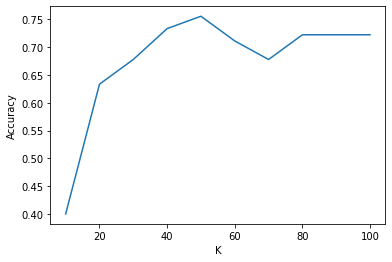

In [27]:
dic_model_edges_expr
import matplotlib.pyplot as plt
print(dic_model_edges_expr["LR"])
plt.plot([i*10 for i in range(1,11)],dic_model_edges_expr["LR"])
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.savefig("edges_EXPR_ML-LR_K.svg",dpi=300)


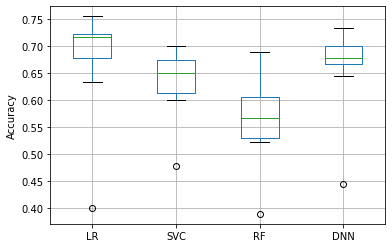

In [27]:
df_edges_expr_plot = pd.DataFrame.from_dict(dic_model_edges_expr)
df_edges_expr_plot.boxplot()
plt.ylabel("Accuracy")
plt.savefig("edges_expr_ML_models.svg",dpi=300)

## gene pos connectivity

In [28]:
connectivity_pos_selected = pd.read_csv("primaryNivo.positive.connectivity_adjusted.txt",index_col=1)
connectivity_neg_selected = pd.read_csv("primaryNivo.negative.connectivity_adjusted.txt",index_col=1)

connec_pos_input = connectivity_pos_selected.loc[modelinput_expr.index,:].iloc[:,1:]
connec_pos_input_improved = modelinput_expr.join(connec_pos_input,lsuffix='expr', rsuffix='conp')
connec_pos_input_improved.shape

connec_neg_input = connectivity_neg_selected.loc[modelinput_expr.index,:].iloc[:,1:]
connec_neg_input_improved = modelinput_expr.join(connec_neg_input,lsuffix='expr', rsuffix='conn')
connec_neg_input_improved.shape

(90, 41090)

In [29]:
connec_pos_input.index == dfcl["Benefit"].index

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

In [30]:
# Spot Check Algorithms

df_connectivity_pos = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ connec_pos_input.copy()],\
        ["connec_pos"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    models.append(('SVC',SVC(class_weight='balanced')))       
    models.append(('RF', RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced')))
    models.append(('DNN',MLPClassifier(activation='relu',solver='adam',random_state=42,max_iter=1000)))
   
    
    dic_model_edges = {}
    for name, model in models:
        results = []
        names = []
        for i in range(1,11):
            # Define leave-one-out cross-validation
            loo = LeaveOneOut()
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            
            for train_index, test_index in loo.split(datetype):
                # Create a pipeline
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('feature_selection', SelectKBest(score_func=f_classif,k=i*10)), 
                    ('logistic_regression', model)       # Logistic Regression model
            ])
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)
                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
                #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        df_connectivity_pos[name] = results
        

LR 0.28888888888888886
LR 0.4
LR 0.45555555555555555
LR 0.5444444444444444
LR 0.5888888888888889
LR 0.5666666666666667
LR 0.5888888888888889
LR 0.5777777777777777
LR 0.6222222222222222
LR 0.5888888888888889
SVC 0.32222222222222224
SVC 0.43333333333333335
SVC 0.4888888888888889
SVC 0.5111111111111111
SVC 0.5555555555555556
SVC 0.5111111111111111
SVC 0.5
SVC 0.5777777777777777
SVC 0.5555555555555556
SVC 0.5555555555555556
RF 0.2777777777777778
RF 0.4222222222222222
RF 0.5555555555555556
RF 0.5111111111111111
RF 0.4777777777777778
RF 0.4666666666666667
RF 0.43333333333333335
RF 0.4888888888888889
RF 0.5111111111111111
RF 0.4888888888888889


/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perce

DNN 0.3888888888888889
DNN 0.45555555555555555
DNN 0.5111111111111111
DNN 0.5777777777777777
DNN 0.6333333333333333
DNN 0.6
DNN 0.6
DNN 0.6
DNN 0.6
DNN 0.5666666666666667


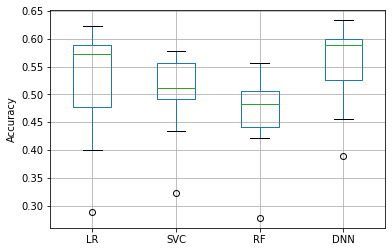

In [40]:
df_connectivity_pos_plot = pd.DataFrame.from_dict(df_connectivity_pos)
df_connectivity_pos_plot.boxplot()
plt.ylabel("Accuracy")
plt.savefig("df_connectivity_pos_ML_models.svg",dpi=300)

In [90]:
connec_neg_input

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1-AS1,A2MP1,A3GALT2,A4GALT,A4GNT,...,BCL2L2-PABPN1,LINC00316,MLIP-IT1,ST7-AS1,IGLV1-50,SPATA19,SETSIP,ZNF774,CYTL1,OR10G3
gene_name,,,,,,,,,,,,,,,,,,,,,
G138701_RCCBMS-00020-T_v1_RNA_OnPrem,20.098340,4.004365,48.230769,23.402286,2.808523,4.985339,0.398209,1.973750,247.125305,21.771941,...,0.373714,0.425165,0.433938,2.456490,0.865243,0.420388,11.864616,0.375820,3.233170,0.411150
G138701_RCCBMS-00097-T_v1_RNA_OnPrem,32.191956,0.400724,28.794606,39.138475,11.451415,0.773871,0.398209,3.095702,259.374971,39.558146,...,0.373714,0.425165,0.433938,0.376722,0.384982,0.420388,10.505523,0.375820,0.381227,0.411150
G138701_RCCBMS-00141-T_v1_RNA_OnPrem,21.580520,0.420987,109.294522,22.865618,3.626327,0.773871,0.398209,3.289209,358.243633,74.941145,...,0.373714,0.425165,0.433938,0.790305,5.986657,0.420388,0.765300,0.375820,5.658303,0.411150
G138701_RCCBMS-00099-T_v1_RNA_OnPrem,22.720399,0.388846,37.036121,73.594223,4.761523,0.773871,0.528614,4.504262,228.642376,21.454868,...,0.373714,0.425165,0.433938,4.396744,1.198339,0.420388,0.422620,0.376824,0.381227,0.411150
G138701_RCCBMS-00053-T_v1_RNA_OnPrem,15.129678,0.387475,117.730794,23.545359,1.735100,17.776733,0.398209,1.225491,227.876408,19.201667,...,1.605246,0.425165,0.433938,0.376722,0.384982,0.420388,0.376115,0.375820,0.381227,0.411150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EA639040,28.495517,0.782693,30.064048,20.565540,3.322309,14.042735,1.057252,7.624272,246.288375,20.374532,...,0.373714,2.315913,0.433938,0.376722,0.384982,0.420388,0.376115,0.375820,0.381227,0.411150
P66507-04D-Run1_S3_L001,12.178283,7.794987,31.057713,169.241725,8.556393,6.149714,1186.749928,1.419029,274.190768,22.236485,...,51.296774,0.425165,0.433938,2.783654,4.525923,0.420388,8.326669,1.220935,16.041997,0.411150
P66507-07G-Run1_S17_L002,3.437975,8.693933,8.158370,5.797169,6.854758,17.661779,0.475258,43.458883,527.308939,3.570280,...,39.945381,0.425165,0.433938,2.980556,4.071402,0.420388,1.809311,98.136528,12.006931,0.411150


In [32]:
# Spot Check Algorithms
# edges_input

df_connectivity_neg = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ connec_neg_input.copy()],\
        ["connec_neg"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    models.append(('SVC',SVC(class_weight='balanced')))       
    models.append(('RF', RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced')))
    models.append(('DNN',MLPClassifier(activation='relu',solver='adam',random_state=42,max_iter=1000)))
   
    
    dic_model_edges = {}
    for name, model in models:
        results = []
        names = []
        for i in range(1,11):
            # Define leave-one-out cross-validation
            loo = LeaveOneOut()
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            
            for train_index, test_index in loo.split(datetype):
                # Create a pipeline
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('feature_selection', SelectKBest(score_func=f_classif,k=i*10)), 
                    ('logistic_regression', model)       # Logistic Regression model
            ])
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)
                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
                #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        df_connectivity_neg[name] = results
        

LR 0.5
LR 0.5
LR 0.5555555555555556
LR 0.4666666666666667
LR 0.35555555555555557
LR 0.37777777777777777
LR 0.3888888888888889
LR 0.43333333333333335
LR 0.43333333333333335
LR 0.4444444444444444
SVC 0.5666666666666667
SVC 0.5666666666666667
SVC 0.5555555555555556
SVC 0.4444444444444444
SVC 0.43333333333333335
SVC 0.4111111111111111
SVC 0.45555555555555555
SVC 0.5
SVC 0.5222222222222223
SVC 0.5555555555555556
RF 0.5111111111111111
RF 0.5555555555555556
RF 0.4666666666666667
RF 0.4777777777777778
RF 0.4
RF 0.5
RF 0.4888888888888889
RF 0.4444444444444444
RF 0.5111111111111111
RF 0.4444444444444444


/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perce

DNN 0.5111111111111111
DNN 0.5666666666666667
DNN 0.5333333333333333
DNN 0.4111111111111111
DNN 0.3333333333333333
DNN 0.3888888888888889
DNN 0.4
DNN 0.4111111111111111
DNN 0.4444444444444444
DNN 0.4111111111111111


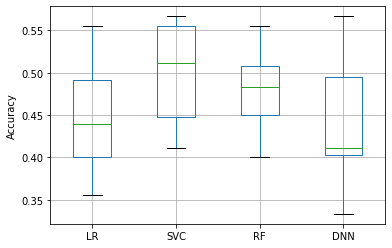

In [41]:
df_connectivity_neg_plot = pd.DataFrame.from_dict(df_connectivity_neg)
df_connectivity_neg_plot.boxplot()
plt.ylabel("Accuracy")
plt.savefig("df_connectivity_neg_ML_models.svg",dpi=300)

## gene pos connectivity + expression

In [33]:
# Spot Check Algorithms
# edges_input

df_connectivity_pos_improved = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ connec_pos_input_improved .copy()],\
        ["expression+gene pos connectivity"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    models.append(('SVC',SVC(class_weight='balanced')))       
    models.append(('RF', RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced')))
    models.append(('DNN',MLPClassifier(activation='relu',solver='adam',random_state=42,max_iter=1000)))
   
    
    dic_model_edges = {}
    for name, model in models:
        results = []
        names = []
        for i in range(1,11):
            # Define leave-one-out cross-validation
            loo = LeaveOneOut()
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            
            for train_index, test_index in loo.split(datetype):
                # Create a pipeline
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('feature_selection', SelectKBest(score_func=f_classif,k=i*10)), 
                    ('logistic_regression', model)       # Logistic Regression model
            ])
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)
                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
                #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        df_connectivity_pos_improved[name] = results
        

LR 0.6444444444444445
LR 0.6
LR 0.4888888888888889
LR 0.5111111111111111
LR 0.5777777777777777
LR 0.5777777777777777
LR 0.6333333333333333
LR 0.6111111111111112
LR 0.5666666666666667
LR 0.5555555555555556
SVC 0.5666666666666667
SVC 0.5666666666666667
SVC 0.5
SVC 0.5333333333333333
SVC 0.5444444444444444
SVC 0.5111111111111111
SVC 0.5333333333333333
SVC 0.5222222222222223
SVC 0.5
SVC 0.4777777777777778
RF 0.5444444444444444
RF 0.5
RF 0.4
RF 0.5
RF 0.4777777777777778
RF 0.5222222222222223
RF 0.4777777777777778
RF 0.4444444444444444
RF 0.4111111111111111
RF 0.3888888888888889
DNN 0.5888888888888889
DNN 0.6222222222222222
DNN 0.5222222222222223
DNN 0.5666666666666667
DNN 0.5444444444444444
DNN 0.5555555555555556
DNN 0.6333333333333333
DNN 0.6111111111111112
DNN 0.5777777777777777
DNN 0.5


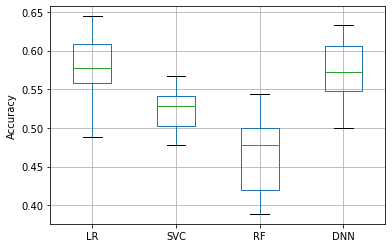

In [42]:
df_connectivity_pos_improved_plot = pd.DataFrame.from_dict(df_connectivity_pos_improved)
df_connectivity_pos_improved_plot.boxplot()
plt.ylabel("Accuracy")
plt.savefig("df_connectivity_pos_improved_ML_models.svg",dpi=300)

## gene neg connectivity + expression

In [34]:
# Spot Check Algorithms
# edges_input

df_connectivity_neg_improved = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ connec_neg_input_improved .copy()],\
        ["expression+gene pos connectivity"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    models.append(('SVC',SVC(class_weight='balanced')))       
    models.append(('RF', RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced')))
    models.append(('DNN',MLPClassifier(activation='relu',solver='adam',random_state=42,max_iter=1000)))
   
    
    dic_model_edges = {}
    for name, model in models:
        results = []
        names = []
        for i in range(1,11):
            # Define leave-one-out cross-validation
            loo = LeaveOneOut()
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            
            for train_index, test_index in loo.split(datetype):
                # Create a pipeline
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('feature_selection', SelectKBest(score_func=f_classif,k=i*10)), 
                    ('logistic_regression', model)       # Logistic Regression model
            ])
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)
                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
                #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        df_connectivity_neg_improved[name] = results
        

LR 0.7111111111111111
LR 0.6222222222222222
LR 0.5666666666666667
LR 0.5444444444444444
LR 0.5444444444444444
LR 0.5222222222222223
LR 0.5444444444444444
LR 0.5333333333333333
LR 0.5
LR 0.4777777777777778
SVC 0.6777777777777778
SVC 0.6
SVC 0.5111111111111111
SVC 0.4888888888888889
SVC 0.5111111111111111
SVC 0.4777777777777778
SVC 0.5333333333333333
SVC 0.4777777777777778
SVC 0.45555555555555555
SVC 0.4777777777777778
RF 0.6333333333333333
RF 0.6333333333333333
RF 0.4777777777777778
RF 0.4888888888888889
RF 0.4777777777777778
RF 0.5222222222222223
RF 0.45555555555555555
RF 0.4444444444444444
RF 0.4444444444444444
RF 0.3888888888888889
DNN 0.7111111111111111
DNN 0.6555555555555556
DNN 0.5888888888888889
DNN 0.5222222222222223
DNN 0.5111111111111111
DNN 0.5
DNN 0.5222222222222223
DNN 0.5444444444444444
DNN 0.5111111111111111
DNN 0.5


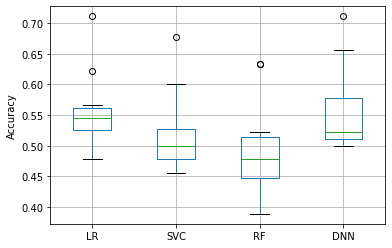

In [43]:
df_connectivity_neg_improved_plot = pd.DataFrame.from_dict(df_connectivity_neg_improved)
df_connectivity_neg_improved_plot.boxplot()
plt.ylabel("Accuracy")
plt.savefig("df_connectivity_neg_improved_ML_models.svg",dpi=300)

# GSVA + entropy

In [35]:
gsva_selected = pd.read_csv("gsva1_c2kegg_pathway_primaryNivo.txt",index_col=0,sep="\t")
entropy_selected = pd.read_csv("c2kegg_pathway_edge_entropy_primaryNivo.txt",index_col=0,sep="\t")

gsva_input = gsva_selected.T.loc[modelinput_expr.index]

print(gsva_input.shape)

entropy_input = entropy_selected.loc[modelinput_expr.index]
entropy_input_improved = gsva_input.join(entropy_input,rsuffix='entropy', lsuffix='gsva')
entropy_input_improved.shape

(90, 186)


(90, 372)

In [36]:
# Spot Check Algorithms
# edges_input

df_gsva_input = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ gsva_input.copy()],\
        ["gsva_input"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    models.append(('SVC',SVC(class_weight='balanced')))       
    models.append(('RF', RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced')))
    models.append(('DNN',MLPClassifier(activation='relu',solver='adam',random_state=42,max_iter=1000)))
   
    
    dic_model_edges = {}
    for name, model in models:
        results = []
        names = []
        for i in range(1,11):
            # Define leave-one-out cross-validation
            loo = LeaveOneOut()
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            
            for train_index, test_index in loo.split(datetype):
                # Create a pipeline
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('feature_selection', SelectKBest(score_func=f_classif,k=i*10)), 
                    ('logistic_regression', model)       # Logistic Regression model
            ])
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)
                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
                #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        df_gsva_input[name] = results
        

LR 0.5
LR 0.3111111111111111
LR 0.36666666666666664
LR 0.37777777777777777
LR 0.3333333333333333
LR 0.32222222222222224
LR 0.3888888888888889
LR 0.4111111111111111
LR 0.4777777777777778
LR 0.4666666666666667
SVC 0.5333333333333333
SVC 0.45555555555555555
SVC 0.43333333333333335
SVC 0.37777777777777777
SVC 0.4222222222222222
SVC 0.43333333333333335
SVC 0.4444444444444444
SVC 0.4444444444444444
SVC 0.4444444444444444
SVC 0.4777777777777778
RF 0.5111111111111111
RF 0.36666666666666664
RF 0.4111111111111111
RF 0.43333333333333335
RF 0.45555555555555555
RF 0.4111111111111111
RF 0.4666666666666667
RF 0.4111111111111111
RF 0.4444444444444444
RF 0.43333333333333335
DNN 0.5
DNN 0.3888888888888889
DNN 0.4
DNN 0.4111111111111111
DNN 0.37777777777777777
DNN 0.4111111111111111
DNN 0.4111111111111111
DNN 0.4222222222222222
DNN 0.4777777777777778
DNN 0.5222222222222223


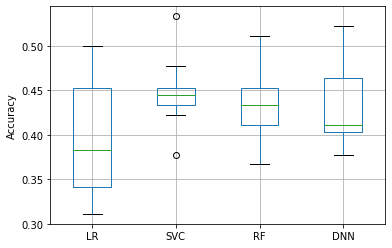

In [44]:
df_gsva_input_plot = pd.DataFrame.from_dict(df_gsva_input)
df_gsva_input_plot.boxplot()
plt.ylabel("Accuracy")
plt.savefig("df_gsva_input_ML_models.svg",dpi=300)

In [101]:
entropy_input.drop(columns=["KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_BIOSYNTHESIS"])

,KEGG_N_GLYCAN_BIOSYNTHESIS,KEGG_OTHER_GLYCAN_DEGRADATION,KEGG_O_GLYCAN_BIOSYNTHESIS,KEGG_GLYCOSAMINOGLYCAN_DEGRADATION,KEGG_GLYCOSAMINOGLYCAN_BIOSYNTHESIS_KERATAN_SULFATE,KEGG_GLYCEROLIPID_METABOLISM,KEGG_GLYCOSYLPHOSPHATIDYLINOSITOL_GPI_ANCHOR_BIOSYNTHESIS,KEGG_GLYCEROPHOSPHOLIPID_METABOLISM,KEGG_ETHER_LIPID_METABOLISM,KEGG_ARACHIDONIC_ACID_METABOLISM,...,KEGG_BLADDER_CANCER,KEGG_CHRONIC_MYELOID_LEUKEMIA,KEGG_ACUTE_MYELOID_LEUKEMIA,KEGG_SMALL_CELL_LUNG_CANCER,KEGG_NON_SMALL_CELL_LUNG_CANCER,KEGG_ASTHMA,KEGG_AUTOIMMUNE_THYROID_DISEASE,KEGG_ALLOGRAFT_REJECTION,KEGG_GRAFT_VERSUS_HOST_DISEASE,KEGG_VIRAL_MYOCARDITIS
gene_name,,,,,,,,,,,,,,,,,,,,,
G138701_RCCBMS-00020-T_v1_RNA_OnPrem,6.343835,4.074794,2.982445,3.675793,0.998114,4.159977,4.381013,6.117762,2.981824,5.032655,...,5.198499,7.387803,6.859232,7.185506,6.380158,5.746887,6.994988,6.951162,6.951162,7.918221
G138701_RCCBMS-00097-T_v1_RNA_OnPrem,6.360813,4.155751,2.981278,3.673274,0.999850,4.078170,4.382102,5.942443,3.302632,4.801503,...,5.232854,7.388234,6.942361,7.385276,6.344080,5.746898,7.136202,7.047064,7.047149,7.974886
G138701_RCCBMS-00141-T_v1_RNA_OnPrem,6.394952,4.307389,2.789488,3.428575,1.998696,4.515003,4.514788,6.357082,3.773858,5.663844,...,5.160802,7.496431,6.847438,7.252601,6.345361,5.822548,7.015355,7.004947,7.004947,8.002298
G138701_RCCBMS-00099-T_v1_RNA_OnPrem,6.445691,4.235665,2.792230,2.965020,0.999432,4.382285,4.384238,6.033195,2.982291,4.638854,...,5.272786,7.445397,7.075387,7.484072,6.477307,5.798968,7.126011,7.056521,7.046043,8.007385
G138701_RCCBMS-00053-T_v1_RNA_OnPrem,6.327206,4.157498,2.300515,2.774957,0.999165,3.895348,4.163274,5.769827,3.788629,4.386265,...,4.849343,7.169887,6.781358,7.008113,6.179122,5.824595,7.039646,7.007987,6.996925,7.988881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EA639040,6.509000,4.156694,2.785762,2.967207,0.998249,3.897367,4.448804,6.178247,3.788811,4.799644,...,5.117391,7.448694,6.990208,7.453290,6.397952,5.748308,7.091846,7.017684,7.006931,7.939148
P66507-04D-Run1_S3_L001,6.443837,4.073597,2.785277,3.139714,0.997293,3.157867,4.316022,5.963678,3.979078,4.799877,...,4.989170,7.160550,6.633433,7.233407,6.077090,5.748321,7.104028,6.976567,6.954132,8.057090
P66507-07G-Run1_S17_L002,6.035381,2.988972,3.448949,1.556017,1.576365,3.680820,5.061378,5.240023,2.799000,3.167395,...,5.160935,7.274681,6.587636,6.833189,6.452404,5.502331,6.602807,6.588536,6.588536,7.507082


In [ ]:
# Spot Check Algorithms
# edges_input

df_entropy_input = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ entropy_input.drop(columns=["KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_BIOSYNTHESIS"]).copy()],\
        ["entropy_input"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    models.append(('SVC',SVC(class_weight='balanced')))       
    models.append(('RF', RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced')))
    models.append(('DNN',MLPClassifier(activation='relu',solver='adam',random_state=42,max_iter=1000)))
   
    
    dic_model_edges = {}
    for name, model in models:
        results = []
        names = []
        for i in range(1,11):
            # Define leave-one-out cross-validation
            loo = LeaveOneOut()
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            
            for train_index, test_index in loo.split(datetype):
                # Create a pipeline
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('feature_selection', SelectKBest(score_func=f_classif,k=i*10)), 
                    ('logistic_regression', model)       # Logistic Regression model
            ])
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)
                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
                #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        df_entropy_input[name] = results
        

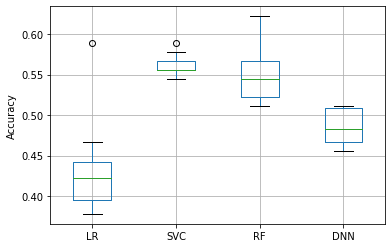

In [45]:
df_entropy_input_plot = pd.DataFrame.from_dict(df_entropy_input)
df_entropy_input_plot.boxplot()
plt.ylabel("Accuracy")
plt.savefig("df_entropy_input_ML_models.svg",dpi=300)

In [38]:
entropy_input_improved.columns

Index(['KEGG_ABC_TRANSPORTERSgsva', 'KEGG_ACUTE_MYELOID_LEUKEMIAgsva',
       'KEGG_ADHERENS_JUNCTIONgsva',
       'KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAYgsva',
       'KEGG_ALANINE_ASPARTATE_AND_GLUTAMATE_METABOLISMgsva',
       'KEGG_ALDOSTERONE_REGULATED_SODIUM_REABSORPTIONgsva',
       'KEGG_ALLOGRAFT_REJECTIONgsva',
       'KEGG_ALPHA_LINOLENIC_ACID_METABOLISMgsva',
       'KEGG_ALZHEIMERS_DISEASEgsva',
       'KEGG_AMINO_SUGAR_AND_NUCLEOTIDE_SUGAR_METABOLISMgsva',
       ...
       'KEGG_BLADDER_CANCERentropy', 'KEGG_CHRONIC_MYELOID_LEUKEMIAentropy',
       'KEGG_ACUTE_MYELOID_LEUKEMIAentropy',
       'KEGG_SMALL_CELL_LUNG_CANCERentropy',
       'KEGG_NON_SMALL_CELL_LUNG_CANCERentropy', 'KEGG_ASTHMAentropy',
       'KEGG_AUTOIMMUNE_THYROID_DISEASEentropy',
       'KEGG_ALLOGRAFT_REJECTIONentropy',
       'KEGG_GRAFT_VERSUS_HOST_DISEASEentropy',
       'KEGG_VIRAL_MYOCARDITISentropy'],
      dtype='object', length=372)

In [ ]:
# Spot Check Algorithms
# edges_input

df_entropy_input_improved = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ entropy_input_improved.drop(columns=["KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_BIOSYNTHESISentropy"]).copy()],\
        ["entropy_input_improved"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    models.append(('SVC',SVC(class_weight='balanced')))       
    models.append(('RF', RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced')))
    models.append(('DNN',MLPClassifier(activation='relu',solver='adam',random_state=42,max_iter=1000)))
   
    
    dic_model_edges = {}
    for name, model in models:
        results = []
        names = []
        for i in range(1,11):
            # Define leave-one-out cross-validation
            loo = LeaveOneOut()
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            
            for train_index, test_index in loo.split(datetype):
                # Create a pipeline
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('feature_selection', SelectKBest(score_func=f_classif,k=i*10)), 
                    ('logistic_regression', model)       # Logistic Regression model
            ])
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)
                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
                #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        df_entropy_input_improved[name] = results
        

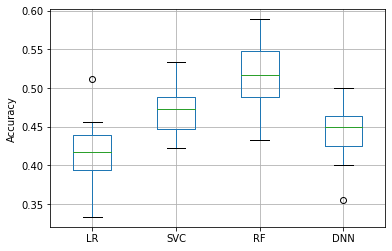

In [46]:
df_entropy_input_improved_plot = pd.DataFrame.from_dict(df_entropy_input_improved)
df_entropy_input_improved_plot.boxplot()
plt.ylabel("Accuracy")
plt.savefig("df_entropy_input_improved_ML_models.svg",dpi=300)